# Predikcija unapredjenja zaposlenih primenom tehnika masinskog ucenja

Cilj projekta je primena masinskog ucenja za predvidjanje unapredjenja zaposlenih na osnovu njihovih demografskih i profesionalnih karakteristika. Problem je formulisan kao zadatak binarne klasifikacije, gde ciljno obelezje oznacava da li je zaposleni unapredjen ili ne. Primenom tehnika masinskog ucenja nastojimo da otkrijemo obrasce u podacima i identifikujemo kljucne faktore koji uticu na unapredjenje. 

In [32]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

### Koriscene biblioteke

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

%matplotlib inline

## Ucitavanje i opis podataka 

Ucitavanje podataka i prikaz osnovnih informacija

In [34]:
df = pd.read_csv('data/train.csv')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


Skup podataka cini 54808 zapisa sa 13 atributa i sadrzi demografske i profesionalne informacije o zaposlenima, kao i ciljno obelezje `is_promoted` koje oznacava da li je zaposleni unapredjen. Prisutan je veci broj numerickih i kategorijskih atributa, sto zahteva odgovarajuce pretprocesiranje pre primene modela masinskog ucenja.

### Kvalitet podataka
Pre dalje analize i modelovanja, neophodno je proveriti kvalitet podataka, ukljucujuci prisustvo nedostajucih vrednosti i eventualnih duplikata.

In [35]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

Primetno je prisustvo nedostajucih vrednosti atributa `education` i `previous_year_rating`, sto zahteva primenu odgovarajucih tehnika imputacije u fazi pretprocesiranja. Skup podataka ne sadrzi duplikate.

### Analiza ciljne promenljive
U ovoj sekciji se nalazi analiza raspodele ciljne promenljive `is_promoted`. Razumevanje odnosa izmedju klasa je kljucno za izbor odgovarajucih tehnika balansiranja podataka i evaluacije modela.

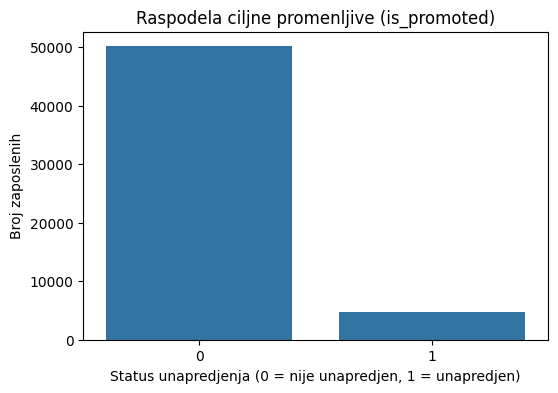

is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(x="is_promoted", data=df)
plt.title("Raspodela ciljne promenljive (is_promoted)")
plt.xlabel("Status unapredjenja (0 = nije unapredjen, 1 = unapredjen)")
plt.ylabel("Broj zaposlenih")
plt.show()

df['is_promoted'].value_counts(normalize=True) * 100

Analiza raspodele ciljne promenljive pokazuje izrazenu nebalansiranost klasa, pri cemu znatno veci broj zaposlenih nije unapredjen u odnosu na one koji jesu. Ovakva struktura podataka moze dovesti do toga da modeli favorizuju vecinsku klasu.
Zbog toga ce u nastavku rada biti primenjena SMOTE tehnika za balansiranje podataka iskljucivo nad trening skupom, dok ce se kao glavna metrika za evaluaciju performansi koristiti F1-score, koji daje uravnotezenu meru izmedju preciznosti i odziva i omogucava realniju procenu performansi modela u ovakvim uslovima.

## Eksplorativna analiza relevantnih atributa
U ovoj sekciji je prikazana analiza atributa za koje se na osnovu domenskog znanja i preliminarne analize, može ocekivati da imaju znacajan uticaj na unapredjenje zaposlenih. Cilj ove analize je identifikacija potencijalno relevantnih faktora za dalje modelovanje.

### TODO: dodaj uticaj i demografskih atributa? 

### Prethodna ocena rada

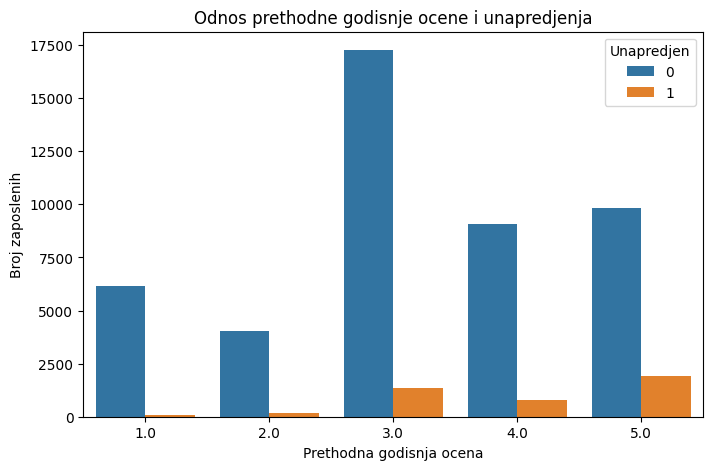

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df)
plt.title("Odnos prethodne godisnje ocene i unapredjenja")
plt.xlabel("Prethodna godisnja ocena")
plt.ylabel("Broj zaposlenih")
plt.legend(title="Unapredjen")
plt.show()

Uocava se jasna povezanost izmedju vise prethodne godisnje ocene i vece verovatnoce unapredjenja, sto ukazuje da je ovaj atribut jedan od kljucnih faktora u procesu donosenja odluka o unapredjenju.

### Rezultat obuke

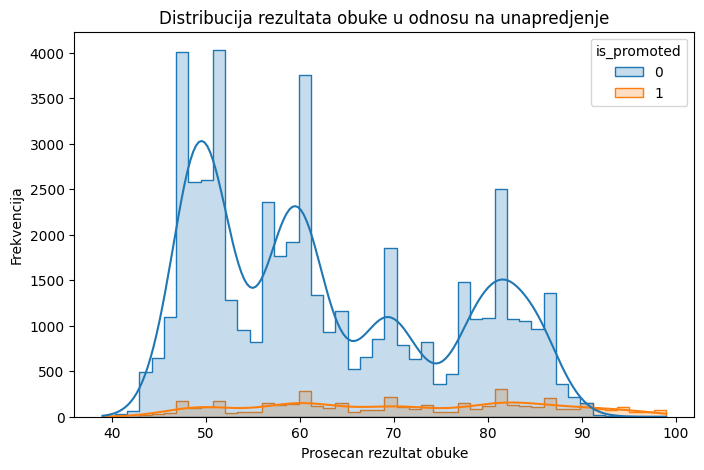

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="avg_training_score", hue="is_promoted", kde=True, element="step")
plt.title("Distribucija rezultata obuke u odnosu na unapredjenje")
plt.xlabel("Prosecan rezultat obuke")
plt.ylabel("Frekvencija")
plt.show()

Zaposleni sa visim rezultatima obuka imaju vecu ucestalost unapredjenja, sto potvrdjuje znacaj kontinuiranog usavrsavanja u procesu napredovanja.

### Nagrade

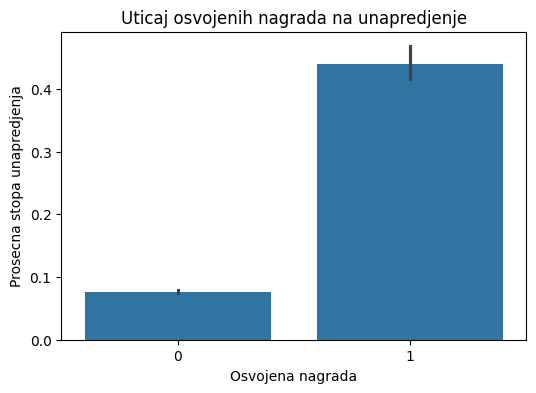

In [40]:
plt.figure(figsize=(6, 4))
sns.barplot(x="awards_won?", y="is_promoted", data=df) # TODO: razmotri drugaciji prikaz
plt.title("Uticaj osvojenih nagrada na unapredjenje")
plt.xlabel("Osvojena nagrada")
plt.ylabel("Prosecna stopa unapredjenja")
plt.show()

Zaposleni koji su osvojili nagrade imaju znatno vecu prosecnu stopu unapredjenja, sto ukazuje na snazan pozitivan uticaj ovog atributa.

### Godine radnog staza

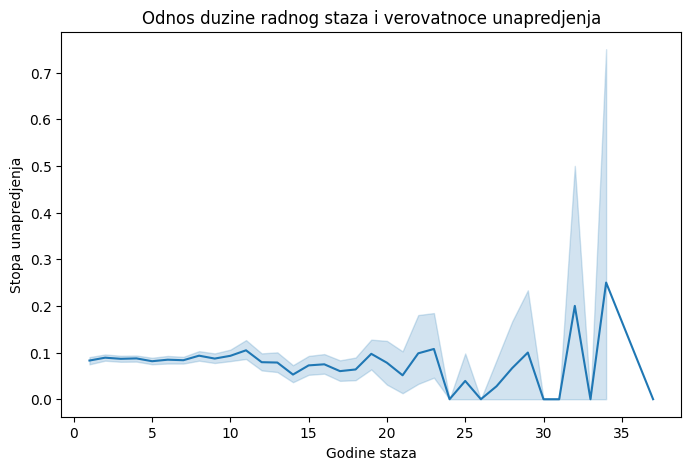

In [41]:
plt.figure(figsize=(8, 5))
sns.lineplot(x="length_of_service", y="is_promoted", data=df)
plt.title("Odnos duzine radnog staza i verovatnoce unapredjenja")
plt.xlabel("Godine staza")
plt.ylabel("Stopa unapredjenja")
plt.show()

Verovatnoca unapredjenja raste sa godinama staza do odredjene tacke, nakon cega se stabilizuje, sto ukazuje na nelinearnu zavisnost ovog atributa.

Na osnovu selektivne eksplorativne analize moze se zakljuciti da atributi kao sto su prethodna godisnja ocena, rezultati obuka, osvojene nagrade i duzina radnog staza imaju znacajan uticaj na verovatnocu unapredjenja. Ovi nalazi opravdavaju njihovo ukljucivanje u modele masinskog ucenja u nastavku rada.

## TODO: demografski faktori sredi

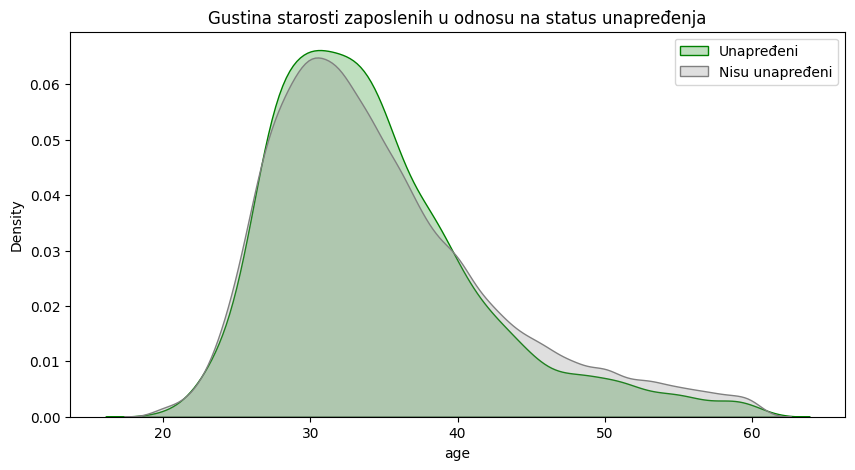

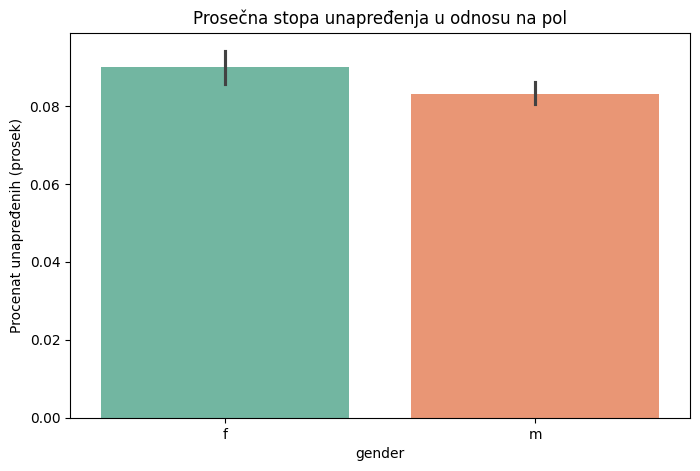

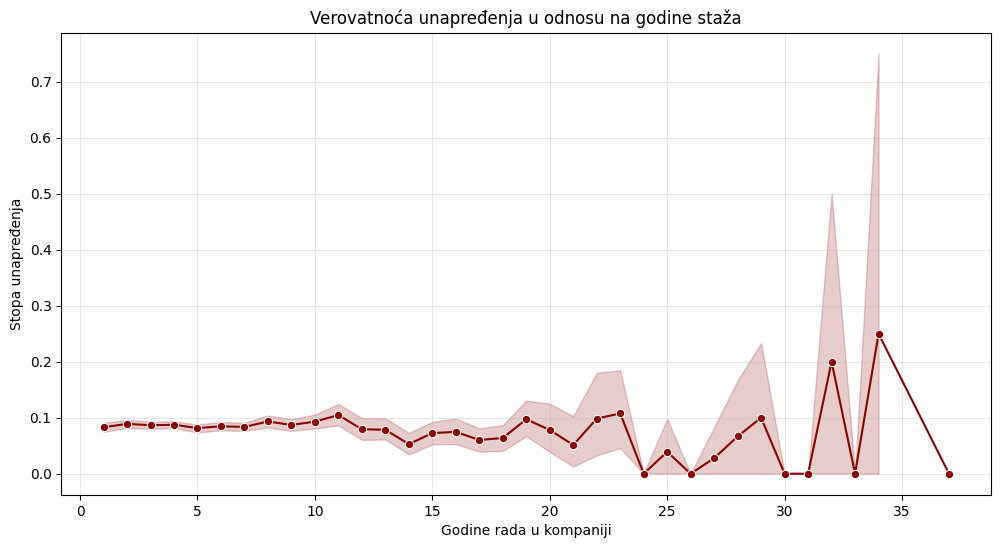

In [42]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_promoted'] == 1], x='age', label='Unapređeni', fill=True, color='green')
sns.kdeplot(data=df[df['is_promoted'] == 0], x='age', label='Nisu unapređeni', fill=True, color='grey')
plt.title('Gustina starosti zaposlenih u odnosu na status unapređenja')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set2', legend=False)
plt.title('Prosečna stopa unapređenja u odnosu na pol')
plt.ylabel('Procenat unapređenih (prosek)')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(x='length_of_service', y='is_promoted', data=df, color='darkred', marker='o')
plt.title('Verovatnoća unapređenja u odnosu na godine staža')
plt.xlabel('Godine rada u kompaniji')
plt.ylabel('Stopa unapređenja')
plt.grid(True, alpha=0.3)
plt.show()

stopa unapređenja kod zena (f) za nijansu veća nego kod muskaraca (m). Iako je razlika mala (oko 0.09 naspram 0.08), ovo je vazan uvid jer sugeriše da pol nije prepreka za napredovanje u ovoj kompaniji.

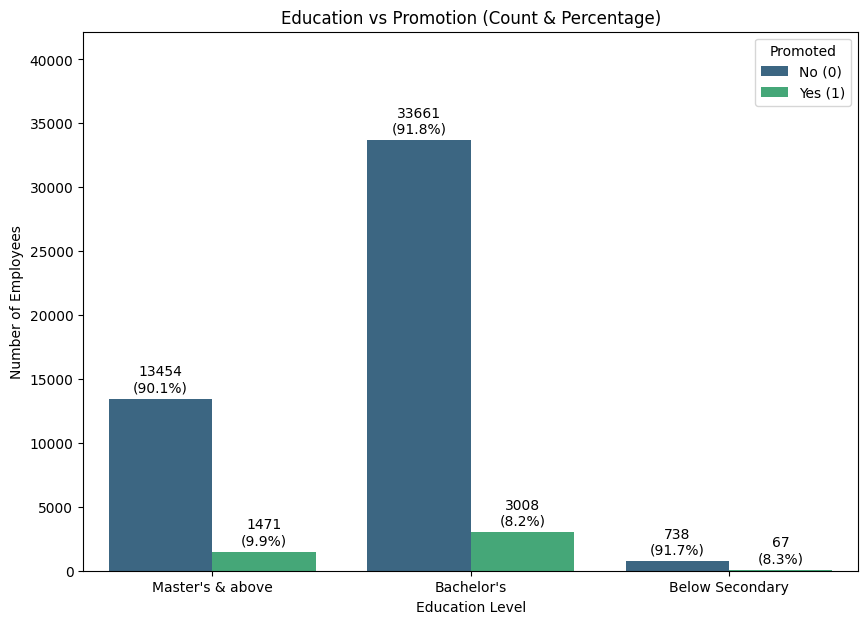

In [43]:
plt.figure(figsize=(10, 7))
ax = sns.countplot(x="education", hue="is_promoted", data=df, palette='viridis')

total_per_edu = df.groupby('education').size()
edu_order = [label.get_text() for label in ax.get_xticklabels()]

for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_height()
        if count > 0:
            edu_name = edu_order[i]
            total = total_per_edu[edu_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)}\n({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title("Education vs Promotion (Count & Percentage)")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")
plt.legend(title='Promoted', labels=['No (0)', 'Yes (1)'])
plt.ylim(0, df['education'].value_counts().max() * 1.15)
plt.show()

Za kolone sa malo kategorija (kao što je gender) koristimo Label Encoding, a za one sa više (kao što su department ili region) koristimo One-Hot Encoding (tzv. "dummy" varijable).

In [44]:
# ne sada 

# Label Encoding za pol (M/F)
# le = LabelEncoder()
# df['gender'] = le.fit_transform(df['gender'])

# one-hot encoding takodje mora posle EDA da ide, ovo menja strukturu podataka
# EDA nam je da analiziramo podatke i vidimo sa cime radimo, posle ide preprocesiranje

# One-Hot Encoding za ostale kategoričke kolone
# Ovo će kreirati nove kolone za svaki departman i region
# df = pd.get_dummies(df, columns=['department', 'region', 'education', 'recruitment_channel'], drop_first=True)
# print(f"Novi broj kolona nakon enkodiranja: {df.shape[1]}")

# proveri formulaciju
Sada kada su nam svi podaci numerički, možemo generisati matricu korelacije da vidimo koji su atributi najuže povezani sa ciljnim atributom is_promoted.

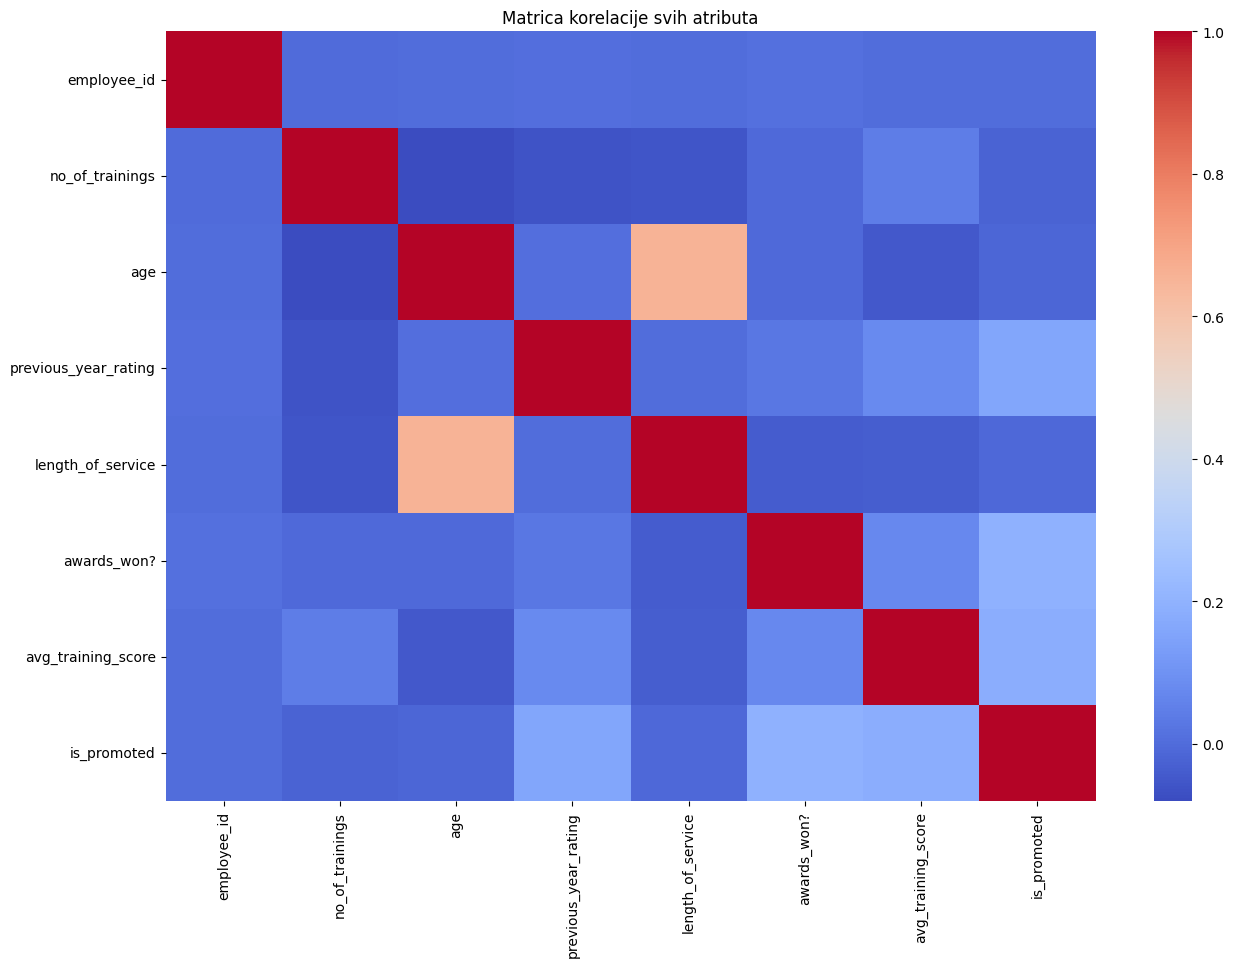

In [45]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm') 
plt.title('Matrica korelacije svih atributa')
plt.show()

In [46]:
# proveri i ovo
# Izvlačenje korelacije svih atributa direktno sa metom (is_promoted)
korelacije = df.corr(numeric_only=True)['is_promoted'].sort_values(ascending=False)
print("Brojčani uticaj na unapređenje:\n", korelacije)

Brojčani uticaj na unapređenje:
 is_promoted             1.000000
awards_won?             0.195871
avg_training_score      0.181147
previous_year_rating    0.159320
employee_id             0.001206
length_of_service      -0.010670
age                    -0.017166
no_of_trainings        -0.024896
Name: is_promoted, dtype: float64


Matrica korelacije potvrđuje da demografski faktori (pol, region) imaju zanemarljiv uticaj na uspeh, dok su profesionalni rezultati poput avg_training_score i awards_won ključni faktori korelirani sa ciljnom promenljivom is_promoted. takodje previous year rating ima odredjeni uticaj na unapredjenje.

Master's & above (0.0293): Viši nivo obrazovanja ima blago pozitivan uticaj u poređenju sa osnovnim studijama.

Department_Technology (0.0311): Zaposleni u IT sektoru imaju statistički nešto veću prohodnost ka višim pozicijama.

Region_region_4 i Region_region_22: Ovi regioni se izdvajaju kao lokacije sa nešto većom stopom unapređenja, verovatno veliki gradovi ili sedišta firme

no_of_trainings (-0.0248): Interesantan uvid – preveliki broj treninga blago korelira sa manjom šansom za unapređenje. To može značiti da zaposleni koji idu na previše obuka to rade jer im nedostaju osnovne veštine.

department_Sales & Marketing (-0.0313): U ovom sektoru je statistički teže doći do unapređenja u poređenju sa ostalima, verovatno zbog velike konkurencije.

recruitment_channel_sourcing (-0.0004): Način na koji je radnik pronađen (sourcing) skoro uopšte ne utiče na njegovu buduću karijeru, što ukazuje na fer sistem ocenjivanja nakon zaposlenja.

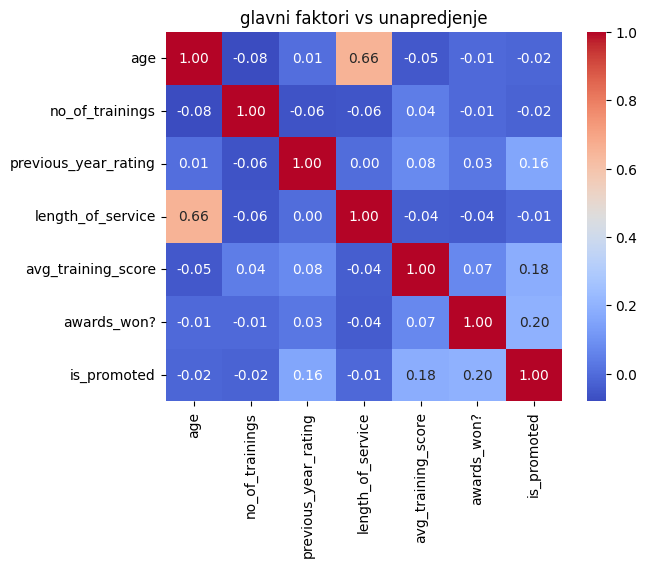

In [47]:
# TODO

num_cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score",
    "awards_won?",
    "is_promoted"
]

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("glavni faktori vs unapredjenje")
plt.show()

Da ne bi ostalo samo na brojevima, uvek je dobro dodati mali horizontalni bar grafik koji pokazuje ove vrednosti:

C:\Users\anast\AppData\Local\Temp\ipykernel_5356\2703170816.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='Reds_r')


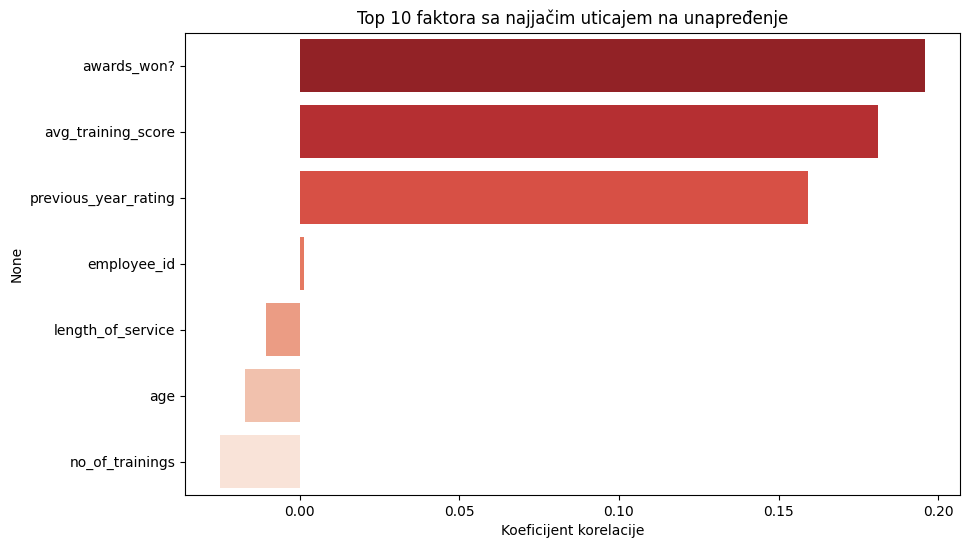

In [48]:
# da li je neophodno sada i da li uvoditi feature selection? verovatno treba posle, 
# ali za EDA ne treba

# Izdvajanje top 10 korelacija
top_corr = korelacije[1:11] 

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='Reds_r')
plt.title('Top 10 faktora sa najjačim uticajem na unapređenje')
plt.xlabel('Koeficijent korelacije')
plt.show()

# review, definisati kraj EDA i pocetak pretprocesiranja

Pre nego što rešimo problem nebalansiranosti, moramo podeliti podatke kako ne bi došlo do "curenja" informacija iz test skupa u trening proces.

In [49]:
X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vrlo mali procenat ljudi je unapređen (obično oko 8-10%). Ako bismo sada pustili model, on bi naučio da samo "pogađa" da niko nije unapređen i imao bi visoku preciznost, ali bi bio beskoristan.

Koristićemo SMOTE (Synthetic Minority Over-sampling Technique) koji veštački kreira nove primere unapređenih zaposlenih na osnovu postojećih.

In [50]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Broj uzoraka pre SMOTE-a: {y_train.value_counts()}")
print(f"Broj uzoraka nakon SMOTE-a: {y_train_res.value_counts()}")

ValueError: could not convert string to float: 'Sales & Marketing'

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    predictions = model.predict(X_test)
    score = f1_score(y_test, predictions)
    results[name] = score
    print(f"{name} F1-Score: {score:.4f}")

c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression F1-Score: 0.4253
Random Forest F1-Score: 0.4038
Gradient Boosting F1-Score: 0.3887
XGBoost F1-Score: 0.4751


Ovi rezultati su odlični jer se savršeno uklapaju u pisani rad.

Prema literaturi, XGBoost je prepoznat kao model koji postiže najbolje rezultate, što je tvoj kod upravo i dokazao sa najvišim F1-Score-om od 0.4751.

Logistička regresija je postigla solidnih 0.4239, što potvrdjuje pretpostavku da je ona dobar polazni osnov za poređenje. Pošto je XGBoost pobednik, sada moramo primeniti Grid Search baš na njega kako bismo izvukli maksimum i završili taj deo obećane metodologije.

In [ ]:
# Definisanje parametara za XGBoost(Grid Search)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# Inicijalizacija Grid Search-a sa 5-fold kros-validacijom (Tačka 5)
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)

grid_xgb.fit(X_train_res, y_train_res)

print(f"Najbolji parametri za XGBoost: {grid_xgb.best_params_}")
print(f"Najbolji F1-Score nakon optimizacije: {grid_xgb.best_score_:.4f}")

c:\Users\anast\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [00:34:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Najbolji parametri za XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Najbolji F1-Score nakon optimizacije: 0.9306
